In [1]:
import os
import io
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import adjusted_rand_score



In [8]:



import matplotlib.pyplot as plt
import urllib.request

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)



In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/tanishq21/Mall-Customers/refs/heads/main/Mall_Customers.csv')

In [3]:


display(df.head())


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:


features = ['Annual Income (k$)', 'Spending Score (1-100)']


print("Using features for clustering:", features)


Using features for clustering: ['Annual Income (k$)', 'Spending Score (1-100)']


In [6]:

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


ks = range(1, 11)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        sil = silhouette_score(X_scaled, km.labels_)
        sil_scores.append(sil)
    else:
        sil_scores.append(np.nan)


d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

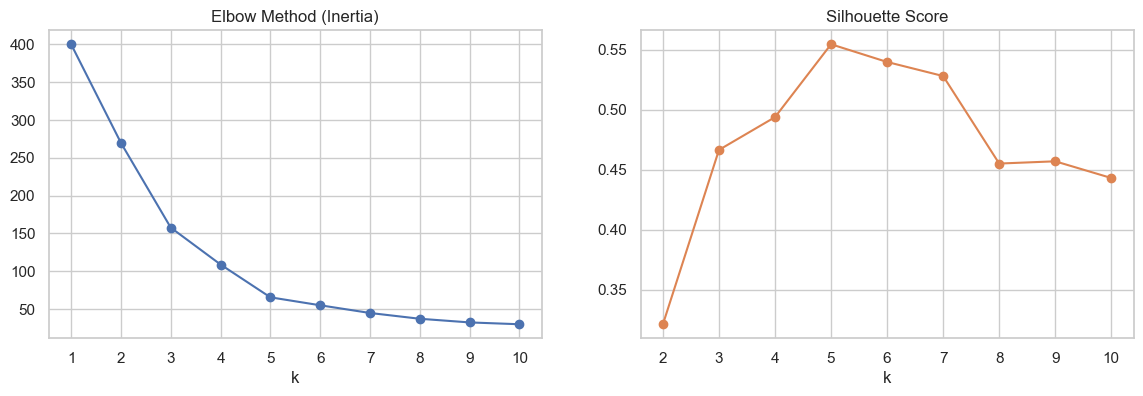

In [10]:

# Plot elbow and silhouette
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(ks, inertias, '-o')
ax[0].set_xlabel('k')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xticks(ks)


ax[1].plot(ks[1:], sil_scores[1:], '-o', color='C1')
ax[1].set_xlabel('k')
ax[1].set_title('Silhouette Score')
ax[1].set_xticks(ks[1:])
plt.show()


In [ ]:

best_k = 5 # maximum silhouette score

# 3) Fit final KMeans and visualize clusters
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

df_km = df.copy()
df_km['kmeans_cluster'] = labels_km



d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


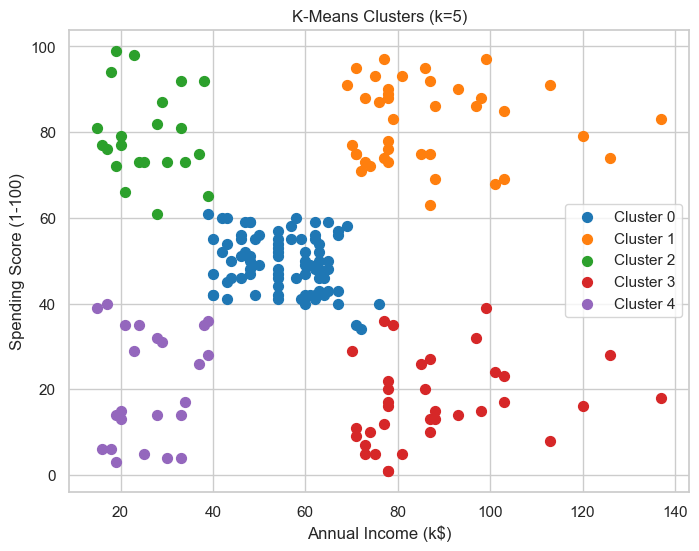

In [13]:

plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", best_k)
for i in range(best_k):
    subset = df_km[df_km['kmeans_cluster'] == i]
    plt.scatter(subset[features[0]], subset[features[1]], s=50, color=palette[i], label=f'Cluster {i}')
#plt.scatter(centers[:, 0], centers[:, 1], s=250, color='black', marker='X', label='Centroids')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f'K-Means Clusters (k={best_k})')
plt.legend()
plt.show()


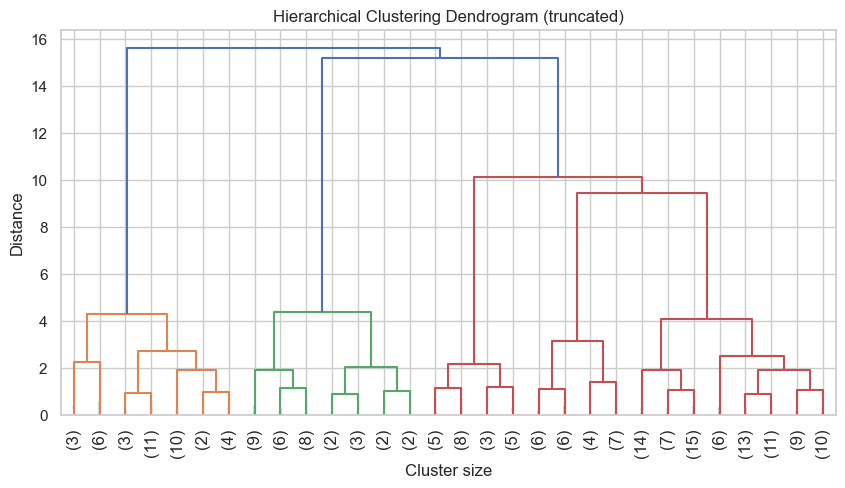

In [14]:


# 4) Hierarchical clustering (agglomerative) and dendrogram
Z = linkage(X_scaled, method='ward')  # ward works well for Euclidean distances

plt.figure(figsize=(10, 5))
dendro = dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()


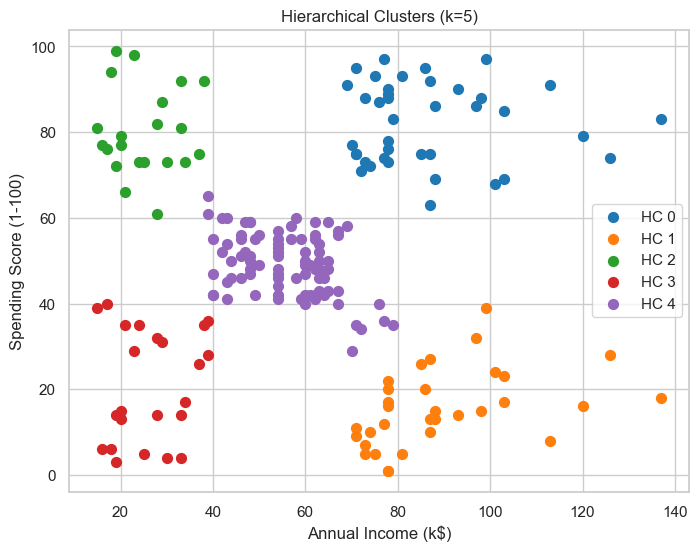

In [15]:

labels_hc = fcluster(Z, t=best_k, criterion='maxclust') - 1  # make zero-based
df_hc = df.copy()
df_hc['hc_cluster'] = labels_hc

# Visualize hierarchical clusters
plt.figure(figsize=(8, 6))
for i in range(best_k):
    subset = df_hc[df_hc['hc_cluster'] == i]
    plt.scatter(subset[features[0]], subset[features[1]], s=50, color=palette[i], label=f'HC {i}')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f'Hierarchical Clusters (k={best_k})')
plt.legend()
plt.show()


In [16]:

print("\nK-Means cluster means (original scale):")
print(df_km.groupby('kmeans_cluster')[features].mean().round(2))
print("\nHierarchical cluster means (original scale):")
print(df_hc.groupby('hc_cluster')[features].mean().round(2))



K-Means cluster means (original scale):
                Annual Income (k$)  Spending Score (1-100)
kmeans_cluster                                            
0                            55.30                   49.52
1                            86.54                   82.13
2                            25.73                   79.36
3                            88.20                   17.11
4                            26.30                   20.91

Hierarchical cluster means (original scale):
            Annual Income (k$)  Spending Score (1-100)
hc_cluster                                            
0                        86.54                   82.13
1                        89.41                   15.59
2                        25.10                   80.05
3                        26.30                   20.91
4                        55.81                   49.13
